# 암종 분류 Baseline 2

## 모델 선택

직전 11-model stacking에서 사용한 후보 풀을 먼저 고정합니다. 수동 피처 설명은 선택에 사용하지 않습니다. 각 outer fold에서 outer-train 행만 사용해 단일 OOF Macro F1 1위를 시작점으로 고르고, 이후에는 이미 선택된 모델들과의 최소 예측 라벨 불일치율이 가장 큰 후보를 하나씩 추가합니다. 동률이면 해당 outer-train 단일 F1과 파일명 순서로 결정합니다.

## OOF 사용

- 각 outer validation의 SUBCLASS는 해당 fold의 모델 선택과 ExtraTrees 학습에 사용하지 않습니다.
- 저장된 base OOF 확률은 고정 meta-feature로 사용합니다.
- 따라서 이 평가는 meta-selection nested CV입니다. 완전한 nested stacking은 11개 base model도 각 outer-train 안에서 다시 inner-OOF로 학습해야 합니다.

## 1. 라이브러리와 경로

In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from deslib.util.diversity import Q_statistic, disagreement_measure, double_fault
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score

from open_cancer.constants import CLASS_LABELS
from open_cancer.validation import validate_submission

root_path = Path.cwd().resolve()
if not (root_path / 'pyproject.toml').exists():
    root_path = root_path.parent

train_path = root_path / 'data/raw/train.csv'
test_path = root_path / 'data/raw/test.csv'
sample_path = root_path / 'data/raw/sample_submission.csv'

fold_file_list = sorted((root_path / 'data/splits').glob('stratified_5fold_*.csv'))
assert len(fold_file_list) == 1
fold_path = fold_file_list[0]

print(root_path)

/Users/fabxoe/workbench/cancer_open


## 2. ID, 클래스, fold 불러오기

In [52]:
train = pd.read_csv(train_path, usecols=['ID', 'SUBCLASS'], dtype=str)
test = pd.read_csv(test_path, usecols=['ID'], dtype=str)
sample_submission = pd.read_csv(sample_path, dtype=str)
fold_data = pd.read_csv(fold_path, dtype={'ID': str, 'fold': int})

assert train['ID'].is_unique
assert test['ID'].is_unique
assert sample_submission['ID'].equals(test['ID'])

fold_map = fold_data.set_index('ID')['fold']
fold_array = train['ID'].map(fold_map).to_numpy(dtype=int)
assert set(fold_array) == {0, 1, 2, 3, 4}

print('train rows:', len(train))
print('test rows:', len(test))

train rows: 6201
test rows: 2546


## 3. 후보 모델 확인

In [53]:
candidate_info = [
    {
        'experiment': 'EXP-639',
        'file_name': 'exp639_parser_v4_hotspot12',
    },
    {
        'experiment': 'EXP-640',
        'file_name': 'exp640_hierarchical_event_stress_parser_qc',
    },
    {
        'experiment': 'EXP-640',
        'file_name': 'exp640_hierarchical_event_stress_combined',
    },
    {
        'experiment': 'EXP-521',
        'file_name': 'exp521_parser_v4_class_cosine',
    },
    {
        'experiment': 'EXP-567',
        'file_name': 'exp567_lightgbm_parser_cosine',
    },
    {
        'experiment': 'EXP-527',
        'file_name': 'exp527_parser_v4_class_cosine_loo',
    },
    {
        'experiment': 'EXP-545',
        'file_name': 'exp545_hierarchical_tfidf_linear',
    },
    {
        'experiment': 'EXP-563',
        'file_name': 'exp563_residue_event_concentration',
    },
    {
        'experiment': 'EXP-334',
        'file_name': 'exp334_exp285_isoform_residue_mask',
    },
    {
        'experiment': 'EXP-285',
        'file_name': 'exp285_exp229_nested_optuna_xgb',
    },
    {
        'experiment': 'EXP-127',
        'file_name': 'exp127_catboost_v1',
    },
]

candidate_table = pd.DataFrame(candidate_info)
assert candidate_table['file_name'].is_unique
display(candidate_table)

,experiment,file_name
0,EXP-639,exp639_parser_v4_hotspot12
1,EXP-640,exp640_hierarchical_event_stress_parser_qc
2,EXP-640,exp640_hierarchical_event_stress_combined
3,EXP-521,exp521_parser_v4_class_cosine
4,EXP-567,exp567_lightgbm_parser_cosine
5,EXP-527,exp527_parser_v4_class_cosine_loo
6,EXP-545,exp545_hierarchical_tfidf_linear
7,EXP-563,exp563_residue_event_concentration
8,EXP-334,exp334_exp285_isoform_residue_mask
9,EXP-285,exp285_exp229_nested_optuna_xgb


## 4. OOF와 test 확률 불러오기

In [54]:
probability_columns = ['PROBA_' + label for label in CLASS_LABELS]
candidate_oof_probability = {}
candidate_test_probability = {}
candidate_prediction = {}
single_model_score_list = []

for info in candidate_info:
    file_name = info['file_name']
    oof_file = root_path / 'oof' / f'{file_name}.csv'
    test_file = root_path / 'preds' / f'{file_name}_test_proba.csv'

    oof_data = pd.read_csv(oof_file, dtype={'ID': str})
    test_data = pd.read_csv(test_file, dtype={'ID': str})

    oof_data = oof_data.set_index('ID').loc[train['ID']].reset_index()
    test_data = test_data.set_index('ID').loc[test['ID']].reset_index()

    assert oof_data['ID'].equals(train['ID'])
    assert test_data['ID'].equals(test['ID'])
    if 'SUBCLASS_TRUE' in oof_data.columns:
        assert oof_data['SUBCLASS_TRUE'].equals(train['SUBCLASS'])

    oof_probability = oof_data[probability_columns].to_numpy(dtype=np.float64)
    test_probability = test_data[probability_columns].to_numpy(dtype=np.float64)

    assert np.isfinite(oof_probability).all()
    assert np.isfinite(test_probability).all()
    assert np.allclose(oof_probability.sum(axis=1), 1.0, atol=1e-5)
    assert np.allclose(test_probability.sum(axis=1), 1.0, atol=1e-5)

    single_prediction = np.asarray(CLASS_LABELS)[oof_probability.argmax(axis=1)]
    candidate_oof_probability[file_name] = oof_probability
    candidate_test_probability[file_name] = test_probability
    candidate_prediction[file_name] = single_prediction
    single_score = f1_score(
        train['SUBCLASS'],
        single_prediction,
        labels=CLASS_LABELS,
        average='macro',
        zero_division=0,
    )
    single_model_score_list.append({
        'experiment': info['experiment'],
        'file_name': file_name,
        'macro_f1': single_score,
    })

single_model_score_table = (
    pd.DataFrame(single_model_score_list)
    .sort_values(['macro_f1', 'file_name'], ascending=[False, True])
    .reset_index(drop=True)
)
display(single_model_score_table)

,experiment,file_name,macro_f1
0,EXP-639,exp639_parser_v4_hotspot12,0.454651
1,EXP-640,exp640_hierarchical_event_stress_parser_qc,0.452075
2,EXP-640,exp640_hierarchical_event_stress_combined,0.449211
3,EXP-521,exp521_parser_v4_class_cosine,0.447993
4,EXP-567,exp567_lightgbm_parser_cosine,0.447742
5,EXP-527,exp527_parser_v4_class_cosine_loo,0.446872
6,EXP-563,exp563_residue_event_concentration,0.439839
7,EXP-545,exp545_hierarchical_tfidf_linear,0.439678
8,EXP-334,exp334_exp285_isoform_residue_mask,0.435134
9,EXP-285,exp285_exp229_nested_optuna_xgb,0.431471


## 5. Outer-train 수치로 5개 모델 선택

선택 개수는 5개로 고정합니다. 선택 함수는 전달받은 행만 사용합니다. 첫 모델은 그 범위의 단일 OOF Macro F1 1위입니다. 다음 모델부터는 각 후보가 이미 선택된 모든 모델과 얼마나 다르게 예측하는지 계산하고, 그중 가장 작은 라벨 불일치율을 후보의 다양성 점수로 사용합니다. 이 최솟값이 가장 큰 후보를 순서대로 선택하고, 동률이면 해당 범위의 단일 Macro F1과 파일명으로 결정합니다. 전체 train 선택은 test 배포 모델에만 사용합니다.

In [55]:
selection_count = 5
info_by_file = {info['file_name']: info for info in candidate_info}


def select_candidate_files(row_indices):
    row_indices = np.asarray(row_indices, dtype=int)
    true_labels = train['SUBCLASS'].to_numpy()[row_indices]
    score_by_file = {}
    for file_name in candidate_table['file_name']:
        score_by_file[file_name] = f1_score(
            true_labels,
            candidate_prediction[file_name][row_indices],
            labels=CLASS_LABELS,
            average='macro',
            zero_division=0,
        )

    selected_file_names = []
    selection_record_list = []
    while len(selected_file_names) < selection_count:
        remaining_file_names = [
            file_name for file_name in candidate_table['file_name']
            if file_name not in selected_file_names
        ]

        if not selected_file_names:
            selected_file_name = sorted(
                remaining_file_names,
                key=lambda file_name: (-score_by_file[file_name], file_name),
            )[0]
            minimum_disagreement = np.nan
            closest_selected = '-'
        else:
            candidate_statistic_list = []
            for file_name in remaining_file_names:
                disagreement_list = [
                    float(np.mean(
                        candidate_prediction[file_name][row_indices]
                        != candidate_prediction[selected_file_name][row_indices]
                    ))
                    for selected_file_name in selected_file_names
                ]
                closest_index = int(np.argmin(disagreement_list))
                candidate_statistic_list.append({
                    'file_name': file_name,
                    'minimum_disagreement': disagreement_list[closest_index],
                    'closest_selected': selected_file_names[closest_index],
                })

            selected_statistic = sorted(
                candidate_statistic_list,
                key=lambda row: (
                    -row['minimum_disagreement'],
                    -score_by_file[row['file_name']],
                    row['file_name'],
                ),
            )[0]
            selected_file_name = selected_statistic['file_name']
            minimum_disagreement = selected_statistic['minimum_disagreement']
            closest_selected = selected_statistic['closest_selected']

        selected_file_names.append(selected_file_name)
        selection_record_list.append({
            'step': len(selected_file_names),
            'experiment': info_by_file[selected_file_name]['experiment'],
            'file_name': selected_file_name,
            'scope_macro_f1': score_by_file[selected_file_name],
            'minimum_label_disagreement': minimum_disagreement,
            'closest_selected': closest_selected,
        })

    assert len(selected_file_names) == selection_count
    assert len(set(selected_file_names)) == selection_count
    return selected_file_names, pd.DataFrame(selection_record_list)


deployment_selected_file_names, deployment_selection_table = select_candidate_files(
    np.arange(len(train))
)
print('전체 train 배포용 선택')
display(deployment_selection_table.style.format({
    'scope_macro_f1': '{:.6f}',
    'minimum_label_disagreement': '{:.4f}',
}, na_rep='-'))

전체 train 배포용 선택


,step,experiment,file_name,scope_macro_f1,minimum_label_disagreement,closest_selected
0,1,EXP-639,exp639_parser_v4_hotspot12,0.454651,-,-
1,2,EXP-545,exp545_hierarchical_tfidf_linear,0.439678,0.4785,exp639_parser_v4_hotspot12
2,3,EXP-127,exp127_catboost_v1,0.419457,0.4057,exp639_parser_v4_hotspot12
3,4,EXP-334,exp334_exp285_isoform_residue_mask,0.435134,0.2716,exp127_catboost_v1
4,5,EXP-640,exp640_hierarchical_event_stress_parser_qc,0.452075,0.2325,exp639_parser_v4_hotspot12


## 6. DESlib 배포 선택 감사

전체 train에서 test 배포용으로 선택된 5개 모델을 외부 오픈소스 도구인 [DESlib diversity API](https://deslib.readthedocs.io/en/latest/modules/util/diversity.html)로 확인합니다. DESlib의 disagreement는 두 모델 중 하나만 맞은 비율이고, double fault는 두 모델이 동시에 틀린 비율이며, Q-statistic은 두 모델의 정오답 연관성을 나타냅니다. 색상은 현재 값의 최솟값과 최댓값에 맞추지 않고 지표의 이론적 범위에 고정합니다. 이 차트는 nested OOF의 fold별 선택을 변경하지 않습니다.

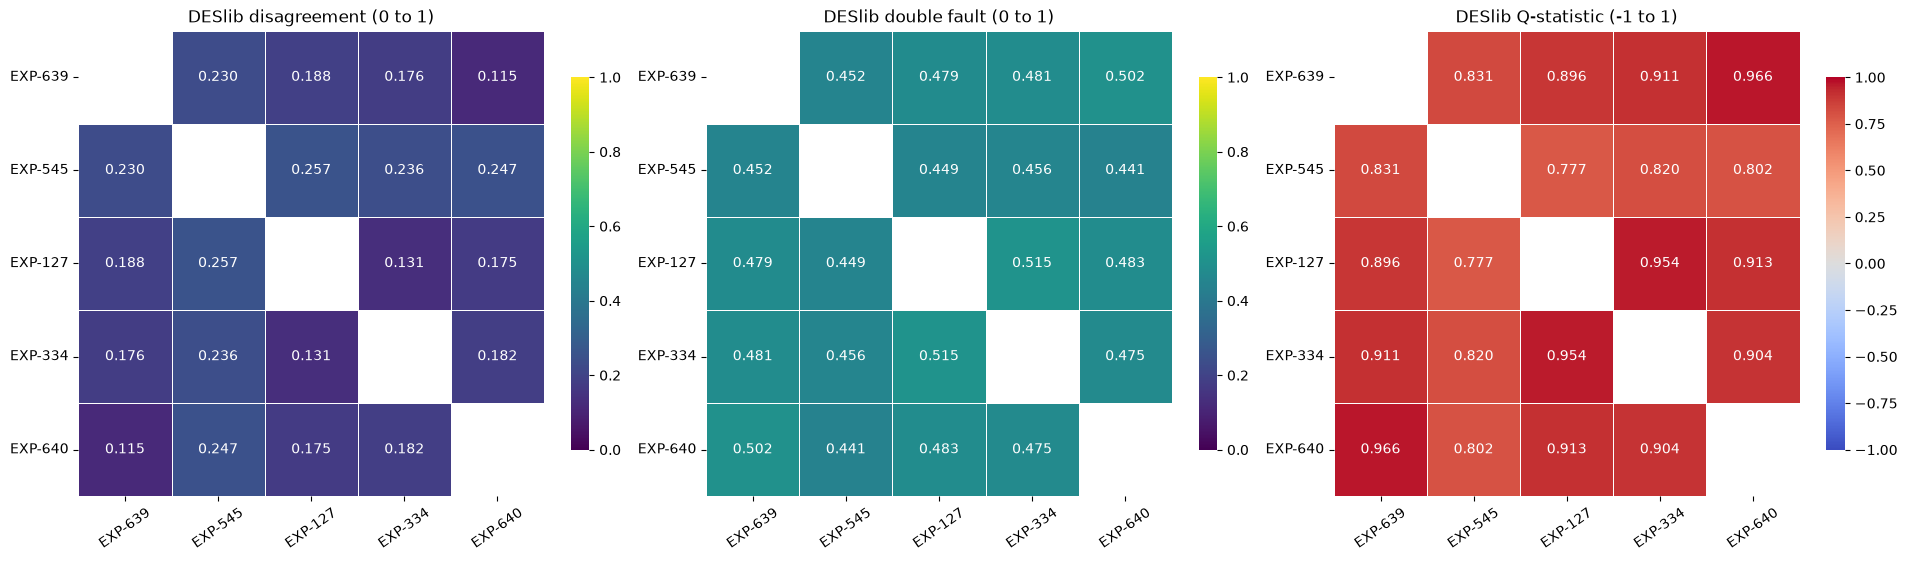

In [56]:
selected_labels = deployment_selection_table['experiment'].tolist()
selected_prediction_list = [
    candidate_prediction[file_name] for file_name in deployment_selected_file_names
]

metric_info = [
    ('DESlib disagreement (0 to 1)', disagreement_measure, 'viridis', 0.0, 1.0),
    ('DESlib double fault (0 to 1)', double_fault, 'viridis', 0.0, 1.0),
    ('DESlib Q-statistic (-1 to 1)', Q_statistic, 'coolwarm', -1.0, 1.0),
]

figure, axes = plt.subplots(1, 3, figsize=(19, 5.5), constrained_layout=True)
for axis, (title, metric_function, color_map, lower_bound, upper_bound) in zip(axes, metric_info):
    metric_matrix = np.full((selection_count, selection_count), np.nan)
    for left_index in range(selection_count):
        for right_index in range(selection_count):
            if left_index != right_index:
                metric_matrix[left_index, right_index] = metric_function(
                    train['SUBCLASS'].to_numpy(),
                    selected_prediction_list[left_index],
                    selected_prediction_list[right_index],
                )

    sns.heatmap(
        metric_matrix,
        mask=np.eye(selection_count, dtype=bool),
        annot=True,
        fmt='.3f',
        cmap=color_map,
        vmin=lower_bound,
        vmax=upper_bound,
        xticklabels=selected_labels,
        yticklabels=selected_labels,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        ax=axis,
    )
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=35)
    axis.tick_params(axis='y', rotation=0)

plt.show()

## 7. Test 배포용 결합 입력 만들기

전체 train 범위에서 선택한 5개 모델의 클래스 확률을 연결합니다. 이 입력은 전체 train 재학습과 test 예측에만 사용합니다. Nested OOF 평가는 다음 절에서 outer fold마다 선택과 입력 생성을 다시 수행합니다.

In [57]:
deployment_x_train = np.concatenate([
    candidate_oof_probability[file_name]
    for file_name in deployment_selected_file_names
], axis=1)
deployment_x_test = np.concatenate([
    candidate_test_probability[file_name]
    for file_name in deployment_selected_file_names
], axis=1)

assert deployment_x_train.shape == (len(train), 5 * len(CLASS_LABELS))
assert deployment_x_test.shape == (len(test), 5 * len(CLASS_LABELS))
assert np.isfinite(deployment_x_train).all()
assert np.isfinite(deployment_x_test).all()

print('deployment_x_train shape:', deployment_x_train.shape)
print('deployment_x_test shape:', deployment_x_test.shape)

deployment_x_train shape: (6201, 130)
deployment_x_test shape: (2546, 130)


## 8. Nested-selection 5-fold 평가

각 outer fold에서 모델 선택 점수와 라벨 불일치율은 outer-train 행으로만 다시 계산합니다. 선택된 5개 확률을 연결해 ExtraTrees를 학습하고, 건드리지 않은 outer validation을 한 번 예측합니다.

In [58]:
oof_prediction = np.empty(len(train), dtype=object)
oof_probability = np.zeros((len(train), len(CLASS_LABELS)), dtype=np.float64)
fold_score_list = []
fold_selection_table_list = []

for fold_number in range(5):
    train_index = np.where(fold_array != fold_number)[0]
    valid_index = np.where(fold_array == fold_number)[0]
    fold_selected_file_names, fold_selection_table = select_candidate_files(train_index)
    fold_selection_table.insert(0, 'outer_fold', fold_number)
    fold_selection_table_list.append(fold_selection_table)

    fold_x_train = np.concatenate([
        candidate_oof_probability[file_name][train_index]
        for file_name in fold_selected_file_names
    ], axis=1)
    fold_x_valid = np.concatenate([
        candidate_oof_probability[file_name][valid_index]
        for file_name in fold_selected_file_names
    ], axis=1)

    model = ExtraTreesClassifier(
        n_estimators=350,
        class_weight='balanced',
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
    )
    model.fit(fold_x_train, train.loc[train_index, 'SUBCLASS'])

    valid_prediction = model.predict(fold_x_valid)
    valid_probability = model.predict_proba(fold_x_valid)
    assert list(model.classes_) == list(CLASS_LABELS)

    oof_prediction[valid_index] = valid_prediction
    oof_probability[valid_index] = valid_probability

    fold_score = f1_score(
        train.loc[valid_index, 'SUBCLASS'],
        valid_prediction,
        labels=CLASS_LABELS,
        average='macro',
        zero_division=0,
    )
    fold_score_list.append(fold_score)
    selected_experiments = [
        info_by_file[file_name]['experiment'] for file_name in fold_selected_file_names
    ]
    print(
        f'fold {fold_number} macro F1: {fold_score:.6f} '
        f'selected: {selected_experiments}'
    )

nested_selection_table = pd.concat(fold_selection_table_list, ignore_index=True)
display(nested_selection_table.style.format({
    'scope_macro_f1': '{:.6f}',
    'minimum_label_disagreement': '{:.4f}',
}, na_rep='-'))

macro_f1 = f1_score(
    train['SUBCLASS'],
    oof_prediction,
    labels=CLASS_LABELS,
    average='macro',
    zero_division=0,
)

assert 0.55 <= macro_f1 <= 0.56
print('Nested-selection OOF Macro F1:', round(macro_f1, 10))
print('fold mean:', round(float(np.mean(fold_score_list)), 10))
print('fold std:', round(float(np.std(fold_score_list)), 10))

fold 0 macro F1: 0.539343 selected: ['EXP-639', 'EXP-545', 'EXP-127', 'EXP-334', 'EXP-640']
fold 1 macro F1: 0.546312 selected: ['EXP-639', 'EXP-545', 'EXP-127', 'EXP-285', 'EXP-640']
fold 2 macro F1: 0.562163 selected: ['EXP-640', 'EXP-545', 'EXP-127', 'EXP-334', 'EXP-563']
fold 3 macro F1: 0.564184 selected: ['EXP-639', 'EXP-545', 'EXP-127', 'EXP-334', 'EXP-640']
fold 4 macro F1: 0.555472 selected: ['EXP-639', 'EXP-545', 'EXP-127', 'EXP-285', 'EXP-640']


,outer_fold,step,experiment,file_name,scope_macro_f1,minimum_label_disagreement,closest_selected
0,0,1,EXP-639,exp639_parser_v4_hotspot12,0.459220,-,-
1,0,2,EXP-545,exp545_hierarchical_tfidf_linear,0.441257,0.4802,exp639_parser_v4_hotspot12
2,0,3,EXP-127,exp127_catboost_v1,0.423681,0.4054,exp639_parser_v4_hotspot12
3,0,4,EXP-334,exp334_exp285_isoform_residue_mask,0.436259,0.2728,exp127_catboost_v1
4,0,5,EXP-640,exp640_hierarchical_event_stress_parser_qc,0.453541,0.2353,exp639_parser_v4_hotspot12
5,1,1,EXP-639,exp639_parser_v4_hotspot12,0.453901,-,-
6,1,2,EXP-545,exp545_hierarchical_tfidf_linear,0.439294,0.4745,exp639_parser_v4_hotspot12
7,1,3,EXP-127,exp127_catboost_v1,0.414619,0.4096,exp639_parser_v4_hotspot12
8,1,4,EXP-285,exp285_exp229_nested_optuna_xgb,0.429808,0.2755,exp127_catboost_v1
9,1,5,EXP-640,exp640_hierarchical_event_stress_parser_qc,0.451121,0.2379,exp639_parser_v4_hotspot12


Nested-selection OOF Macro F1: 0.553048291
fold mean: 0.5534947646
fold std: 0.0094359112


## 9. 전체 데이터로 배포 모델 학습하고 저장

In [59]:
final_model = ExtraTreesClassifier(
    n_estimators=350,
    class_weight='balanced',
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
final_model.fit(deployment_x_train, train['SUBCLASS'])
assert list(final_model.classes_) == list(CLASS_LABELS)

test_prediction = final_model.predict(deployment_x_test)
test_probability = final_model.predict_proba(deployment_x_test)

oof_result = pd.DataFrame({
    'ID': train['ID'],
    'SUBCLASS_TRUE': train['SUBCLASS'],
    'SUBCLASS_PRED': oof_prediction,
    'FOLD': fold_array,
})
test_probability_result = pd.DataFrame({'ID': test['ID']})

for column_index, column_name in enumerate(probability_columns):
    oof_result[column_name] = oof_probability[:, column_index]
    test_probability_result[column_name] = test_probability[:, column_index]

oof_output_path = root_path / 'oof/baseline2_nested_selection_extratrees_stack.csv'
test_probability_path = root_path / 'preds/baseline2_nested_selection_extratrees_stack_test_proba.csv'
submission_path = root_path / 'submissions/baseline2_submission.csv'

oof_result.to_csv(oof_output_path, index=False, lineterminator='\n')
test_probability_result.to_csv(test_probability_path, index=False, lineterminator='\n')

submission = sample_submission.copy()
submission['SUBCLASS'] = test_prediction
submission.to_csv(submission_path, index=False, lineterminator='\n')

submission_check = validate_submission(submission_path, test_path)
print('OOF:', oof_output_path)
print('test probability:', test_probability_path)
print('submission:', submission_path)
submission_check

OOF: /Users/fabxoe/workbench/cancer_open/oof/baseline2_nested_selection_extratrees_stack.csv
test probability: /Users/fabxoe/workbench/cancer_open/preds/baseline2_nested_selection_extratrees_stack_test_proba.csv
submission: /Users/fabxoe/workbench/cancer_open/submissions/baseline2_submission.csv


{'rows': 2546,
 'columns': ['ID', 'SUBCLASS'],
 'label_counts': {'ACC': 30,
  'BLCA': 40,
  'BRCA': 151,
  'CESC': 71,
  'COAD': 496,
  'DLBC': 48,
  'GBMLGG': 111,
  'HNSC': 37,
  'KIPAN': 195,
  'KIRC': 73,
  'LAML': 45,
  'LGG': 55,
  'LIHC': 45,
  'LUAD': 61,
  'LUSC': 27,
  'OV': 111,
  'PAAD': 17,
  'PCPG': 52,
  'PRAD': 131,
  'SARC': 55,
  'SKCM': 65,
  'STES': 385,
  'TGCT': 61,
  'THCA': 60,
  'THYM': 40,
  'UCEC': 84},
 'sha256': '2e9760536b74106deda2875e407d56a1f6a35c1247527d9408184bf6508831ba'}